In [1]:
import re
import pandas as pd
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
import adam_core.coordinates
import pyarrow as pa
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, get_sun, GCRS


In [2]:
import re
import pandas as pd
from urllib.request import urlopen
from io import StringIO
import numpy as np

url = "https://www2.boulder.swri.edu/~davidn/NEOMOD_Simulator/input_neomod3.dat"


text = urlopen(url).read().decode("utf-8", errors="ignore")
lines = text.splitlines()

# to find the header row
header_idx = next(
    i for i, ln in enumerate(lines)
    if re.match(r"^\s*iH\s+ia\s+ie\s+ii\s+binned\s+mod\.\s+nu6\b", ln)
)

# merging binned and mod. into one, otherwise it becomes weird :\
raw_tokens = re.split(r"\s+", lines[header_idx].strip())
names = []
i = 0
while i < len(raw_tokens):
    if raw_tokens[i] == "binned" and i + 1 < len(raw_tokens) and raw_tokens[i+1].startswith("mod."):
        names.append("binned mod.")
        i += 2
    else:
        names.append(raw_tokens[i])
        i += 1

#skips blank or dashed lines
data_lines = []
for ln in lines[header_idx + 1:]:
    s = ln.strip()
    if not s or set(s) <= set("- "):    # separators/blank
        continue
    if re.match(r"^\d", s):             
        data_lines.append(s)


df = pd.read_csv(StringIO("\n".join(data_lines)), sep=r"\s+", header=None, names=names)


df.head()

,iH,ia,ie,ii,binned mod.,nu6,3:1,5:2,7:3,8:3,9:4,11:5,2:1,inner,Hun,Pho,JFC
0,1,4,1,1,1.454600e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,4,1,2,2.115800e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,4,1,3,1.917400e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,4,1,4,3.305900e-09,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,4,1,10,1.983600e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#to calc center of bins
n_H, H_min, H_max = 52, 15.0, 28.0
n_a, a_min, a_max = 42, 0.0, 4.2
n_e, e_min, e_max = 25, 0.0, 1.0
n_i, i_min, i_max = 22, 0.0, 88.0

da = (a_max - a_min)/(n_a) #bin width
de = (e_max - e_min)/(n_e)
di = (i_max - i_min)/(n_i)
dH = (H_max - H_min)/n_H

#bin center coords
a_center = a_min + (np.arange(n_a) + 0.5) * da
e_center = e_min + (np.arange(n_e) + 0.5) * de
i_center = i_min + (np.arange(n_i) + 0.5) * di
H_center = H_min + (np.arange(n_H) + 0.5) * dH

array4D = np.zeros((n_H, n_a, n_e, n_i))

idx = df[['iH', 'ia', 'ie', 'ii']].astype(int).values - 1  # 0-based indices
vals = df['binned mod.'].astype(float).values
array4D[idx[:,0], idx[:,1], idx[:,2], idx[:,3]] = vals

df["a_AU"] = a_min + (df["ia"] - 0.5) * da 
df["e"] = e_min + (df["ie"] - 0.5) * de

In [4]:
AU_km = 149_597_870.7

# creates a right-handed vector basis that points to object from observer
def sky_basis(ra_rad, dec_rad):
        l_hat = np.array([cos(dec_rad)*cos(ra_rad), # vector that points to object's pos on sky from observer
                          cos(dec_rad)*sin(ra_rad),
                          sin(dec_rad)])
        e_ra  = np.array([-sin(ra_rad),  cos(ra_rad), 0.0]) # vector towards increasing RA - points east, 90 deg to l_hat
        e_dec = np.array([-sin(dec_rad)*cos(ra_rad), # vector towards increasing dec - points north
                          -sin(dec_rad)*sin(ra_rad),
                          cos(dec_rad)])
        return l_hat, e_ra, e_dec # turning angular rates into linear velocities

# converts vectors to geocentric state vectors 
def observables_to_geocentric_state(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day,
                                    d_au, ddot_kms, ra_rate_is_plain_dalpha=False):
        # converting from degrees to radians
        ra  = np.deg2rad(ra_deg) 
        dec = np.deg2rad(dec_deg)
        l_hat, e_ra, e_dec = sky_basis(ra, dec)
         # angular rate conversion from deg/day to rad/s
        dra  = np.deg2rad(dra_deg_per_day)  / 86400.0
        ddec = np.deg2rad(ddec_deg_per_day) / 86400.0
        # if the RA rate is plain d alpha/dt, convert to u alpha⋅cos delta sky-plane rate
        if ra_rate_is_plain_dalpha:
             dra *= np.cos(dec)

        d_km = d_au * AU_km
        # multiplying l_hat by the rand dist. value gives actual geocentric pos vector of obj
        r_geo = d_km * l_hat  # vector from earth center to obj

        # speed
        v_rad = ddot_kms * l_hat
        v_tan = d_km * (dra * e_ra + ddec * e_dec)
        v_geo = v_rad + v_tan
        
        return r_geo, v_geo

#converts geocentric vectors to topocentric vectors 
def geo_to_topo(r_geo_km, v_geo_kms, rE, vE, r_obs, obstime):
        # convert r_geo, v_geo for obj to heliocentric r_topo, v_topo for an observer at rubin
        # from center of earth to an observer now at rubin
        obstime = Time(obstime)
        # earth's barycentric (heliocentric) state was done in previous step
        # so was observer's offset from center of earth
        # adding the offsets
        r_topo = rE + r_obs + r_geo_km
        v_topo = vE + v_geo_kms
        return r_topo, v_topo # asteroid position, vec going from sun to asteroid assuming youre at rubin
    

def safe_arccos(x):
        return np.arccos(np.clip(x, -1.0, 1.0))

def neomod3_slice_ae(H0, i0, a_grid, e_grid, interp4D): #fixes H, i, and creates a mesh of a, e
        pts = np.column_stack([np.full(a_grid.size, H0),
                               a_grid.ravel(),
                               e_grid.ravel(),
                               np.full(a_grid.size, i0)])
        log_w = interp4D(pts)
        w = np.exp(log_w).reshape(a_grid.shape)
        return w

def neomod3_at_orbit(a_val, e_val, H0, i0, interp4D):
        log_w = interp4D([[H0, a_val, e_val, i0]])[0]
        return float(np.exp(log_w))


def score_from_elements(a_AU, e, H0, i0, interp4D):
    # checks if orbit is bound right
    if (a_AU <= 0) or (e >= 1.0) or (e < 0):
        
        return 0.0

    # clip gently to model box
    a_cl = np.clip(a_AU, 0.0, 4.2 - 1e-9)
    e_cl = np.clip(e,      0.0, 1.0 - 1e-9)
    i_cl = np.clip(i0,  0.0, 88.0 - 1e-9)

    log_w = float(interp4D([[H0, a_cl, e_cl, i_cl]])[0])
    return 0.0 if not np.isfinite(log_w) else float(np.exp(log_w))


    
def compute_neomod3_weight(d_au, ddot_kms, 
                           ra_deg=10.0, dec_deg=20.0, 
                           dra_deg_per_day=0.12, ddec_deg_per_day=0.22,
                           H0=19.0, i0=25.9, obstime_str="2025-09-16T00:00:00", what="w"):
    obstime = Time(obstime_str)
    ra_rate_is_plain_dalpha = False
    
    

    
    

    rubin_location = EarthLocation.from_geodetic( 
        lon=-70.7366*u.deg,   # longitude (west is negative)
        lat=-30.2407*u.deg,   # latitude
        height=2647*u.m       # elevation
        
    )
    # earth's barycentric vector rel to sun
    with solar_system_ephemeris.set('de432s'): 
        rE_bary, vE_bary = get_body_barycentric_posvel('earth', obstime)

    # convert to km and km/s arrays
    rE = np.array([rE_bary.x.to(u.km).value, #rE goes from sun to earth center
                   rE_bary.y.to(u.km).value,
                   rE_bary.z.to(u.km).value])
    
    vE = np.array([vE_bary.x.to(u.km/u.s).value, #vE goes from sun to earth center
                   vE_bary.y.to(u.km/u.s).value,
                   vE_bary.z.to(u.km/u.s).value])
    
    obs_geo = rubin_location.get_gcrs(obstime)
    r_obs = np.array([obs_geo.cartesian.x.to(u.km).value,
                      obs_geo.cartesian.y.to(u.km).value,
                      obs_geo.cartesian.z.to(u.km).value])
 

    r_geo, v_geo = observables_to_geocentric_state(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day, d_au, ddot_kms)

    r_helio, v_helio = geo_to_topo(r_geo, v_geo, rE, vE, r_obs, obstime) #so not running the random numbers anymore

    #print("Heliocentric position [km]:", r_helio)
    #print("Heliocentric velocity [km/s]:", v_helio)



    mu_sun = 1.32712440018e11  # [km^3/s^2] gm of the sun
    r_vec = np.array(r_helio, dtype=float)
    v_vec = np.array(v_helio, dtype=float)
    #print(r_vec)
    #print(v_vec)

    
    r = np.array(r_vec, dtype=float)
    v = np.array(v_vec, dtype=float)
    R = np.linalg.norm(r)
    V = np.linalg.norm(v)

    #r_helio = np.array([ 1.49731310e+08, -1.54951809e+07, -4.56222082e+06 ])  # km
    #r_vec here does the same thing but doesnt use random values so 
    #v_helio = np.array([ 4.15172845, 25.02778897, 12.21628245 ]) # km/s
    #same with v_vec 
    
    obstime = Time(["2025-09-16T00:00:00"], scale="tdb")  # Note converted this to a list 
    if r_vec.ndim == 1:
        r_vec = r_vec[np.newaxis, :]
        v_vec = v_vec[np.newaxis, :]
        #print("r_vec:", r_vec)



    
    cartesian_coordinates = CartesianCoordinates.from_kwargs(
        x=r_vec[:, 0] / KM_P_AU,
        y=r_vec[:, 1] / KM_P_AU,
        z=r_vec[:, 2] / KM_P_AU,
        vx=v_vec[:, 0] / KM_P_AU * S_P_DAY,
        vy=v_vec[:, 1] / KM_P_AU * S_P_DAY,
        vz=v_vec[:, 2] / KM_P_AU * S_P_DAY,
        time=Timestamp.from_astropy(obstime),
        origin=Origin.from_kwargs(code=pa.repeat("SUN", len(r_vec))),
        frame="equatorial" # ecliptic is the other choice
    )
    
    keplerian_coordinates = cartesian_coordinates.to_keplerian()
    
    
    # Might be useful to store them into an orbits object:
    orbits = Orbits.from_kwargs(
        orbit_id=[f"orbit_{i:08d}" for i in range(len(cartesian_coordinates))],
        coordinates=cartesian_coordinates,
    )
    # The Orbits class expects cartesian coordinates but its trivial to convert
    # so that log(0) doesn't happen
    _eps = 1e-300
    log_grid = np.log(array4D + _eps)
    interp4D = RegularGridInterpolator(
        (H_center, a_center, e_center, i_center),
        log_grid,
        bounds_error=False,
        fill_value=-np.inf
    )
    

    # fixed vals
    #H0 = 19.0         # abs magnitude
    #i0 = 10.0         # deg

    Na, Ne = 200, 200
    a_grid = np.linspace(a_min, a_max, Na)
    e_grid = np.linspace(e_min, e_max, Ne)
    A, E = np.meshgrid(a_grid, e_grid, indexing="xy")

    #W = neomod3_slice_ae(H0, i0, A, E, interp4D)    

    

    #a_val, e_val = 0.915, 0.109
    a_val = keplerian_coordinates.a[0].as_py()
    e_val = keplerian_coordinates.e[0].as_py()
    i_val = keplerian_coordinates.i[0].as_py()
    #print(keplerian_coordinates.a)
    #print("a_val:",a_val)
    #print("e_val:",e_val)

    #print("PRE about to call neomod3_at_orbit")

    
    
    score = score_from_elements(a_val, e_val, 19.0, i_val, interp4D)
    return score,a_val,e_val,i_val
    

    
    #print(f"a = {a_val}, e = {e_val}")
    if what=="w":
        return score
    elif what=="a":
        return a_val
    elif what=="e":
        return e_val
    elif what=="i":
        return i_val
    
    

        
        
    
    
    
    
                         
        
                   
                          

In [5]:
test_neomod = compute_neomod3_weight( 
    d_au = 0.20,
    ddot_kms = 3.0,
    
)

print("NEOMOD3 weight score, a, e , i:", test_neomod)

NEOMOD3 weight score, a, e , i: (0.39767976093480417, 1.8347951398904847, 0.37040854569986875, 26.1070747588787)


In [6]:
neo_score, a, e, i = compute_neomod3_weight(d_au=0.20, ddot_kms=3.0)


test_neomod = compute_neomod3_weight( 
    d_au = 0.20,
    ddot_kms = 3.0,
    
)

print("NEOMOD3 weight score, a, e , i:", test_neomod)
print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

NEOMOD3 weight score, a, e , i: (0.39767976093480417, 1.8347951398904847, 0.37040854569986875, 26.1070747588787)
neo_score: 0.39767976093480417
a: 1.8347951398904847
e: 0.37040854569986875
i: 26.1070747588787


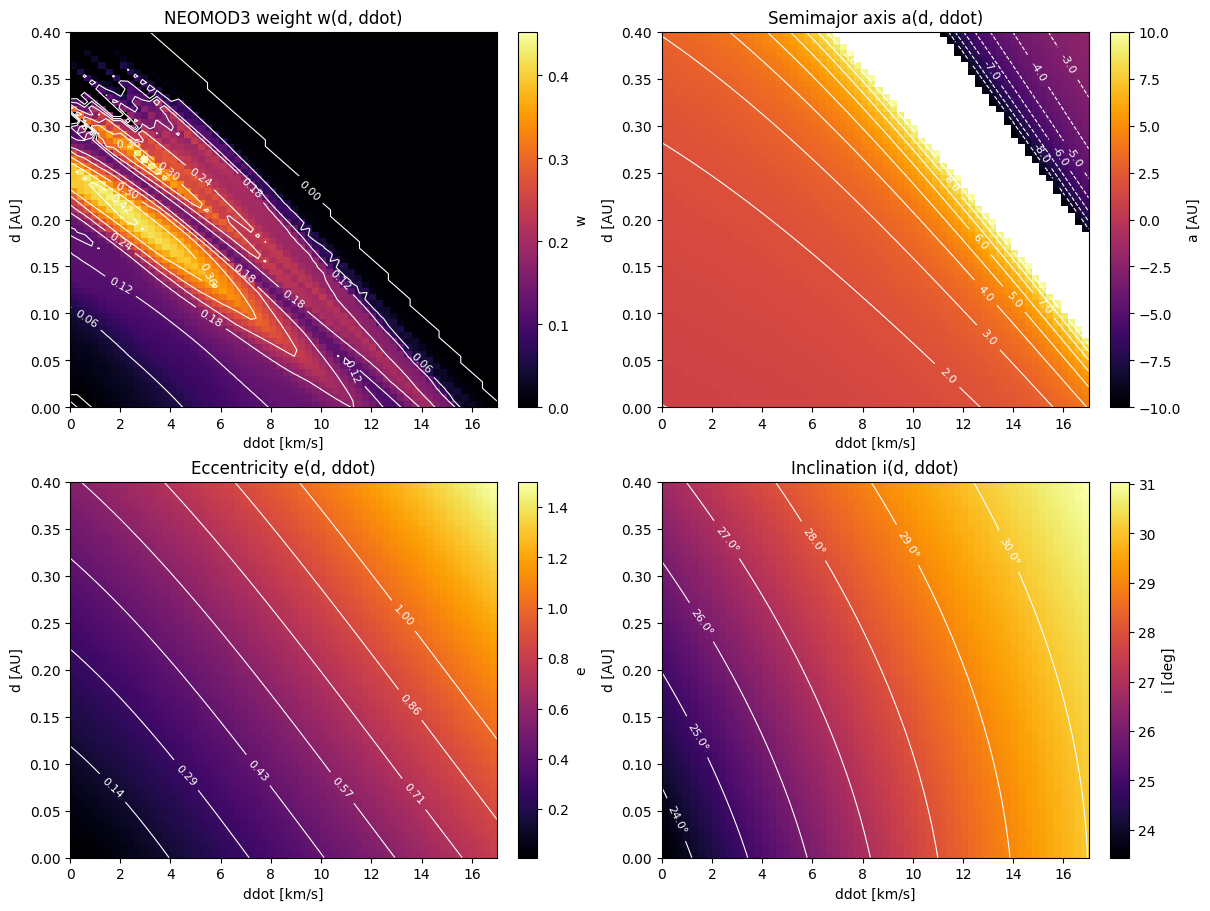

In [11]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 0.40, 60)   
v_vals = np.linspace(0.0, 17.0, 60)    


W = np.zeros((len(d_vals), len(v_vals)))   
A = np.zeros_like(W)                       
E = np.zeros_like(W)                       
I = np.zeros_like(W)                       


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc = compute_neomod3_weight(d_au=d, ddot_kms=v) 
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc


fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d

im0 = axs[0, 0].imshow(W, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(
    A_mask,
    origin="lower",
    extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
    aspect="auto",
    cmap="inferno",
    norm=norm,
)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#im1 = axs[0, 1].imshow(A, origin="lower", extent=extent, aspect="auto", cmap="inferno", vmin=-10, vmax=10)
#cont1 = axs[0,1].contour(v_vals, d_vals, A, levels=8, colors='white', linewidths=0.8)
#axs[0,1].clabel(cont1, inline=True, fontsize=8, fmt="%.2f")

#img1 = np.copy(im1)
#img1 = np.ma.masked_where(np.abs(img1) > 10, img1)
#plt.contour(x, y, img1, levels=np.linspace(-10, 10, 21))

#axs[0, 1].set_title("Semimajor axis a(d, ddot)")
#axs[0, 1].set_xlabel("ddot [km/s]")
#axs[0, 1].set_ylabel("d [AU]")
#fig.colorbar(im1, ax=axs[0, 1], label="a [AU]")

#eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

#inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()


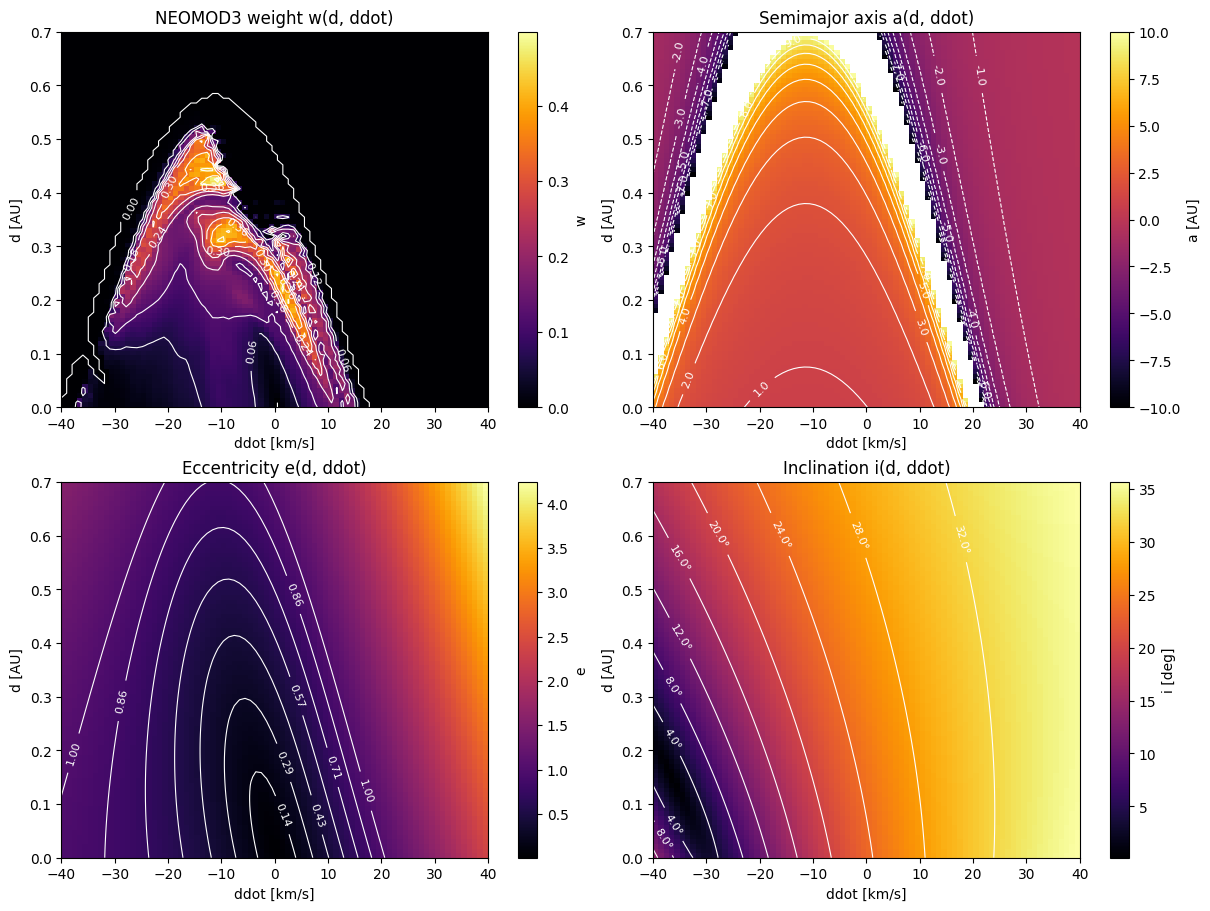

In [12]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 0.70, 80)   
v_vals = np.linspace(-40.0, 40.0, 80)    


W = np.zeros((len(d_vals), len(v_vals)))   
A = np.zeros_like(W)                       
E = np.zeros_like(W)                       
I = np.zeros_like(W)                       


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc = compute_neomod3_weight(d_au=d, ddot_kms=v) 
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc


fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d

im0 = axs[0, 0].imshow(W, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(
    A_mask,
    origin="lower",
    extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
    aspect="auto",
    cmap="inferno",
    norm=norm,
)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#im1 = axs[0, 1].imshow(A, origin="lower", extent=extent, aspect="auto", cmap="inferno", vmin=-10, vmax=10)
#cont1 = axs[0,1].contour(v_vals, d_vals, A, levels=8, colors='white', linewidths=0.8)
#axs[0,1].clabel(cont1, inline=True, fontsize=8, fmt="%.2f")

#img1 = np.copy(im1)
#img1 = np.ma.masked_where(np.abs(img1) > 10, img1)
#plt.contour(x, y, img1, levels=np.linspace(-10, 10, 21))

#axs[0, 1].set_title("Semimajor axis a(d, ddot)")
#axs[0, 1].set_xlabel("ddot [km/s]")
#axs[0, 1].set_ylabel("d [AU]")
#fig.colorbar(im1, ax=axs[0, 1], label="a [AU]")

#eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

#inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()


In [13]:
from astropy.coordinates import SkyCoord, get_body, GCRS, GeocentricTrueEcliptic

obstime = Time("2025-09-23T00:00:00", scale="utc")
obj = SkyCoord(ra=150*u.deg, dec=10*u.deg, frame = "icrs")
obj_to_ecl = obj.transform_to(GeocentricTrueEcliptic(obstime=obstime))

print(f" Ecliptic longitude (lambda): {obj_to_ecl.lon:.3f}")
print(f" Ecliptic latitude (lambda): {obj_to_ecl.lat:.3f}")

 Ecliptic longitude (lambda): 148.579 deg
 Ecliptic latitude (lambda): -2.094 deg


In [14]:

ra_list  = np.array([10, 50, 120, 200, 300]) * u.deg
dec_list = np.array([5, -10, 20, -5, 15]) * u.deg

coords_eq = SkyCoord(ra=ra_list, dec=dec_list, frame="icrs")
coords_ecl = coords_eq.transform_to(GeocentricTrueEcliptic(obstime=obstime))


print("lambda (deg):", coords_ecl.lon.deg)
print("beta (deg):", coords_ecl.lat.deg)


lambda (deg): [ 11.15260078  44.5473097  118.01935215 200.34415686 306.00852059]
beta (deg): [  0.6390404  -27.34689896  -0.56790862   3.18546154  34.76742629]


In [15]:


obstime = Time("2025-09-23T00:00:00", scale="utc")


ra_list  = np.linspace(0, 360, 300) * u.deg
dec_list = np.random.uniform(-30, 30, size=300) * u.deg


coords_eq  = SkyCoord(ra=ra_list, dec=dec_list, frame="icrs")
coords_ecl = coords_eq.transform_to(GeocentricTrueEcliptic(obstime=obstime))

lam = coords_ecl.lon.deg   # ecliptic longitude
bet = coords_ecl.lat.deg   # ecliptic latitude


In [16]:

weights = np.array([compute_neomod3_weight(d_au=0.5, ddot_kms=2.0)[0] for _ in lam])


In [17]:
# define a grid for d_au (start at 0-5au) and ddot(-60, to 60) 
# for each pixel you integrate over with d, ddot 


In [18]:
import numpy as np

# ---------- angular-rate converter: (dra, ddec) -> (v_lambda, v_beta) ----------
def radec_rates_to_ecliptic_rates(ra_deg, dec_deg, dra_deg_day, ddec_deg_day):
    """
    Convert equatorial sky motion to ecliptic sky motion at the same direction.

    Parameters
    ----------
    ra_deg, dec_deg : float
        Right ascension and declination of the direction (deg).
    dra_deg_day, ddec_deg_day : float
        Angular rates on the sky (deg/day). dra is d(alpha)*cos(delta)/day.

    Returns
    -------
    v_lambda, v_beta : float
        Ecliptic longitude and latitude rates (deg/day).
    """
    ra  = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    
    e_ra  = np.array([-np.sin(ra),  np.cos(ra), 0.0])
    e_dec = np.array([-np.sin(dec)*np.cos(ra), -np.sin(dec)*np.sin(ra), np.cos(dec)])

    # Angular velocity vector in equatorial Cartesian 
    dra  = np.deg2rad(dra_deg_day)  / 86400.0
    ddec = np.deg2rad(ddec_deg_day) / 86400.0
    w_eq = dra*e_ra + ddec*e_dec

    # Rotation from equatorial to ecliptic 
    eps = np.deg2rad(23.439291)
    R = np.array([[ 1,           0,            0],
                  [ 0,  np.cos(eps),  np.sin(eps)],
                  [ 0, -np.sin(eps),  np.cos(eps)]])
    w_ecl = R @ w_eq


    
    l_hat_eq = np.array([np.cos(dec)*np.cos(ra),
                         np.cos(dec)*np.sin(ra),
                         np.sin(dec)])
    l_hat_ecl = R @ l_hat_eq
    lam = np.arctan2(l_hat_ecl[1], l_hat_ecl[0])
    bet = np.arcsin(l_hat_ecl[2])

    e_lam = np.array([-np.sin(lam),  np.cos(lam),  0.0])
    e_bet = np.array([-np.sin(bet)*np.cos(lam),
                      -np.sin(bet)*np.sin(lam),
                       np.cos(bet)])

    vlam  = np.dot(w_ecl, e_lam) * 86400.0 * 180.0/np.pi
    vbeta = np.dot(w_ecl, e_bet) * 86400.0 * 180.0/np.pi
    return vlam, vbeta


In [19]:
def weight_only(*args, **kwargs):
    """
    Call compute_neomod3_weight and return only the weight (score).
    Works whether the function returns a scalar or a (score, a, e, i) tuple.
    """
    out = compute_neomod3_weight(*args, **kwargs)
    
    return out[0] if isinstance(out, tuple) else float(out)


In [20]:
d_min, d_max, Nd = 0.05, 5.0, 10          # AU  
v_min, v_max, Nv = -60.0, 60.0, 10         # km/s

d_grid   = np.linspace(d_min, d_max, Nd)
ddot_grid= np.linspace(v_min, v_max, Nv)


def weight_marginalized_over_d_and_ddot(ra_deg, dec_deg, dra_deg_day, ddec_deg_day,
                                        H0=19.0, i0=25.9, obstime_str="2025-09-23T00:00:00"):
    w_sum = 0.0
    for d in d_grid:
        for vlos in ddot_grid:
            w = weight_only(d_au=d,
                            ddot_kms=vlos,
                            ra_deg=ra_deg, dec_deg=dec_deg,
                            dra_deg_per_day=dra_deg_day, ddec_deg_per_day=ddec_deg_day,
                            H0=H0, i0=i0, obstime_str=obstime_str, what="w")
            w_sum += w
    return w_sum



In [21]:
import matplotlib.pyplot as plt

# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0
obstime_str = "2025-09-23T00:00:00"

 
N_rate = 31
dra_vals  = np.linspace(-0.6, 0.6, N_rate)
ddec_vals = np.linspace(-0.6, 0.6, N_rate)


vlam_edges = np.linspace(-0.6, 0.6, 121)
vbet_edges = np.linspace(-0.6, 0.6, 121)


H = np.zeros((len(vbet_edges)-1, len(vlam_edges)-1), dtype=float)

for dra in dra_vals:
    for ddec in ddec_vals:
        vlam, vbet = radec_rates_to_ecliptic_rates(ra0_deg, dec0_deg, dra, ddec)
        w_int = weight_marginalized_over_d_and_ddot(ra0_deg, dec0_deg, dra, ddec,
                                                    H0=19.0, i0=25.9, obstime_str=obstime_str)
        
        i = np.searchsorted(vlam_edges, vlam) - 1
        j = np.searchsorted(vbet_edges, vbet) - 1
        if 0 <= i < H.shape[1] and 0 <= j < H.shape[0]:
            H[j, i] += w_int




/tmp/ipykernel_1010944/3145799062.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


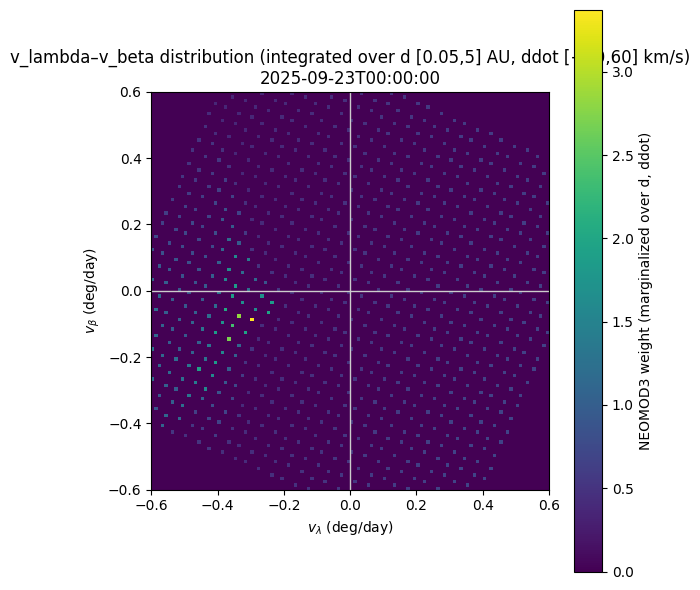

In [22]:
# CELL ABOVE TAKES 9 MINS TO RUN DO NOT RUN AGAIN ON ACCIDENT OR ITS AN UNSKIPPABLE CUTSCENE!!!
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
extent = [vlam_edges[0], vlam_edges[-1], vbet_edges[0], vbet_edges[-1]]


my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(H, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.title("v_lambda–v_beta distribution (integrated over d [0.05,5] AU, ddot [−60,60] km/s)\n"
          f"{obstime_str}")
plt.tight_layout()
plt.show()
